In [ ]:
from flask import Flask, request, jsonify
import pickle
import tensorflow as tf
from keras.models import load_model


In [ ]:
!pip install gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.9/322.9 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.1 MB/s eta 0:00:00


In [ ]:
# Import necessary libraries
import gradio as gr
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array

# Load trained models
cnn_model = load_model("cnn_model.h5")
mobilenet_model = load_model("mobilenet_model.h5")
resnet_model = load_model("resnet_model.h5")

# Load the Random Forest model
with open("rf_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

# Disease mapping and recovery tips
disease_map = {
    0: "🌿 Bacterial Leaf Blight",
    1: "🍂 Brown Spot",
    2: "✅ Healthy Leaf",
    3: "🔥 Leaf Blast",
    4: "💦 Leaf Scald",
    5: "🌾 Narrow Brown Spot"
}

recovery_tips = {
    "🌿 Bacterial Leaf Blight": "🚜 Spray streptomycin or copper fungicides and manage water properly.",
    "🍂 Brown Spot": "🌱 Apply nitrogen fertilizers and avoid water stress.",
    "🔥 Leaf Blast": "🛡️ Use fungicides like tricyclazole and ensure proper plant spacing.",
    "✅ Healthy Leaf": "🎉 Your crop is healthy! Maintain regular care.",
    "💦 Leaf Scald": "💧 Control irrigation and improve soil drainage.",
    "🌾 Narrow Brown Spot": "⚗️ Apply fungicides containing mancozeb or carbendazim.",
    "❓ Unknown Disease": "🔍 Consult an agricultural specialist for further investigation."
}

# Function to preprocess the image
def preprocess_image(image):
    image = image.resize((224, 224))  # Resize the input image
    img_array = img_to_array(image) / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Prediction function using all three models
def predict(image):
    try:
        preprocessed_image = preprocess_image(image)

        # Get predictions from all models
        cnn_pred = np.argmax(cnn_model.predict(preprocessed_image))
        mobilenet_pred = np.argmax(mobilenet_model.predict(preprocessed_image))
        resnet_pred = np.argmax(resnet_model.predict(preprocessed_image))

        # Majority voting for final prediction
        predictions = [cnn_pred, mobilenet_pred, resnet_pred]
        final_pred = max(set(predictions), key=predictions.count)  # Most common prediction
        disease_name = disease_map.get(final_pred, "❓ Unknown Disease")
        recovery_tip = recovery_tips.get(disease_name, "🧐 No specific prevention measures available.")

        return f"""<div style="background-color:#eef9e8; padding:10px; border-radius:10px;">
            <h2>🌿 <b>Predicted Disease:</b> {disease_name}</h2>
            <h4>🤖 <b>Model Predictions:</b></h4>
            <ul>
                <li>📌 CNN Model: {disease_map.get(cnn_pred, "❓ Unknown Disease")}</li>
                <li>📌 MobileNetV2 Model: {disease_map.get(mobilenet_pred, "❓ Unknown Disease")}</li>
                <li>📌 ResNet Model: {disease_map.get(resnet_pred, "❓ Unknown Disease")}</li>
            </ul>
            <p style="font-size:16px;">🛠️ <b>Recommended Action:</b> {recovery_tip}</p>
            <p style="color:gray; font-style:italic;">🔍 Upload more images for better analysis.</p>
        </div>"""

    except Exception as e:
        return f"""<div style="background-color:#ffcccc; padding:10px; border-radius:10px;">
            <h2>⚠️ <b>Error:</b> {str(e)}</h2>
        </div>"""

# Build the Gradio interface
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="📷 Upload a leaf image"),
    outputs=gr.HTML(),
    title="🍃 **Rice Leaf Disease Prediction** 🌾",
    description="📷 Upload an image of a leaf to identify diseases using CNN, MobileNetV2, and ResNet. The model will analyze the image and provide recovery tips.",
    theme="grass",
    live=True
)

# Launch the interface
interface.launch()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gradio/blocks.py:1116: UserWarning: Cannot load grass. Caught Exception: 404 Client Error: Not Found for url: https://huggingface.co/api/spaces/grass (Request ID: Root=1-68161cc3-2a529ea3118556c76415e717;69368e20-6e87-44c8-8faf-70ec7fbf882e)

Sorry, we can't find the page you are looking for.
  warnings.warn(f"Cannot load {theme}. Caught Exception: {str(e)}")


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3f39e76bf1d719d979.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Load TensorFlow/Keras models
from tensorflow.keras.models import load_model
cnn_model = load_model('cnn_model.h5')
mobilenet_model = load_model("mobilenet_model.h5")
resnet_model = load_model("resnet_model.h5")

with open("rf_model.pkl", "rb") as f:
    rf_model = pickle.load(f)


OSError: Unable to synchronously open file (truncated file: eof = 3145728, sblock->base_addr = 0, stored_eof = 11548512)

In [ ]:
# Import necessary libraries
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
import cv2
import pickle

# Load trained models
cnn_model = load_model("cnn_model.h5")
mobilenet_model = load_model("mobilenet_model.h5")
resnet_model = load_model("resnet_model.h5")

# Load the Random Forest model
with open("rf_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

# Disease mapping and recovery tips
disease_map = {
    0: "Bacterial Leaf Blight",
    1: "Brown Spot",
    2: "Healthy Leaf",
    3: "Leaf Blast",
    4: "Leaf Scald",
    5: "Narrow Brown Spot"
}
recovery_tips = {
    "Bacterial Leaf Blight": "Spray streptomycin or copper fungicides and manage water properly.",
    "Brown Spot": "Apply nitrogen fertilizers and avoid water stress.",
    "Leaf Blast": "Use fungicides like tricyclazole and ensure proper plant spacing.",
    "Healthy Leaf": "Your crop is healthy! Maintain regular care.",
    "Leaf Scald": "Control irrigation and improve soil drainage.",
    "Narrow Brown Spot": "Apply fungicides containing mancozeb or carbendazim.",
    "Unknown Disease": "Consult an agricultural specialist for further investigation."
}

# Function to preprocess the image for deep learning models
def preprocess_image(image):
    image = image.resize((224, 224))  # Resize the input image
    img_array = img_to_array(image) / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Function to extract features for the Random Forest model
def extract_features(image):
    image = np.array(image)  # Convert PIL image to a NumPy array
    resized_image = cv2.resize(image, (224, 224))  # Resize image to a fixed size
    gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale

    # Example features: mean, variance, and histogram (first 4 bins)
    mean = np.mean(gray_image)
    variance = np.var(gray_image)
    hist = cv2.calcHist([gray_image], [0], None, [256], [0, 256]).flatten()[:4]  # First 4 bins of histogram

    # Combine all features into a single array
    features = np.array([mean, variance, *hist])
    return features

# Prediction function using all models
def predict(image):
    try:
        # Preprocess the image for deep learning models
        preprocessed_image = preprocess_image(image)

        # Predictions from CNN, MobileNet, and ResNet
        cnn_pred = np.argmax(cnn_model.predict(preprocessed_image))
        mobilenet_pred = np.argmax(mobilenet_model.predict(preprocessed_image))
        resnet_pred = np.argmax(resnet_model.predict(preprocessed_image))

        # Extract features for the Random Forest model
        rf_features = extract_features(image)
        rf_pred = rf_model.predict(rf_features.reshape(1, -1))[0]

        # Combine all model predictions
        predictions = [cnn_pred, mobilenet_pred, resnet_pred, rf_pred]
        final_prediction = max(set(predictions), key=predictions.count)  # Most common prediction

        # Map the prediction to the disease name
        disease_name = disease_map.get(final_prediction, "Unknown Disease")

        # Get recovery tips for the predicted disease
        recovery_tip = recovery_tips.get(disease_name, "No specific prevention measures available.")

        # Return the results
        return f"Disease: {disease_name}\nAction: {recovery_tip}"

    except Exception as e:
        # Return any errors encountered during processing
        return f"Error: {str(e)}"

# Build the Gradio interface
interface = gr.Interface(
    fn=predict,                    # Prediction function
    inputs=gr.Image(type="pil"),   # Image input (PIL format)
    outputs="text",                # Text output to display results
     title="🍃 Rice Leaf Disease Prediction",
    description="Upload an image of a leaf to identify diseases and get prevention tips."
)

# Launch the interface
interface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9185c2afa1a130dfea.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


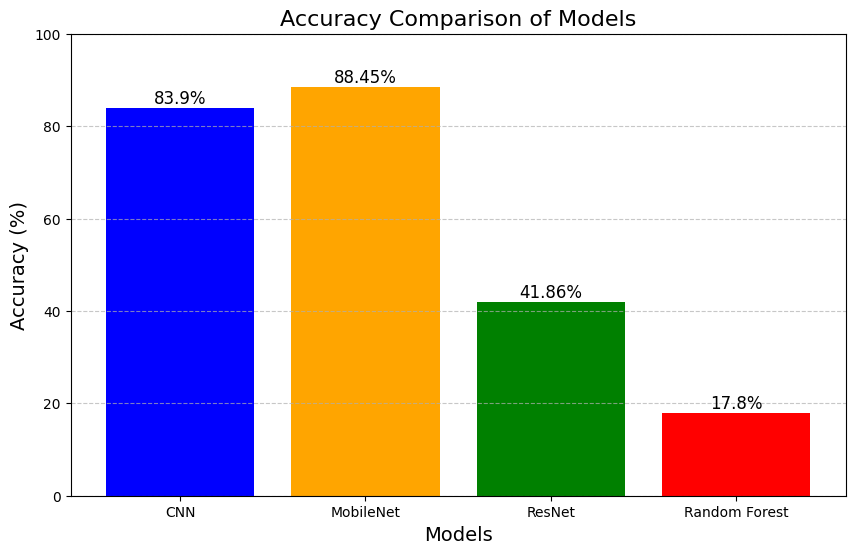

In [ ]:
import matplotlib.pyplot as plt

# Define the accuracy values for your models (replace these with the actual accuracies of your models)
models = ['CNN', 'MobileNet', 'ResNet', 'Random Forest']
accuracies = [83.9, 88.45, 41.86, 17.80]  # Example accuracies in percentages

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'orange', 'green', 'red'])

# Add titles and labels
plt.title('Accuracy Comparison of Models', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.ylim(0, 100)  # Set the scale of the y-axis from 0 to 100
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v}%", ha='center', fontsize=12, color='black')  # Display accuracy values on top of bars

# Show the graph
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


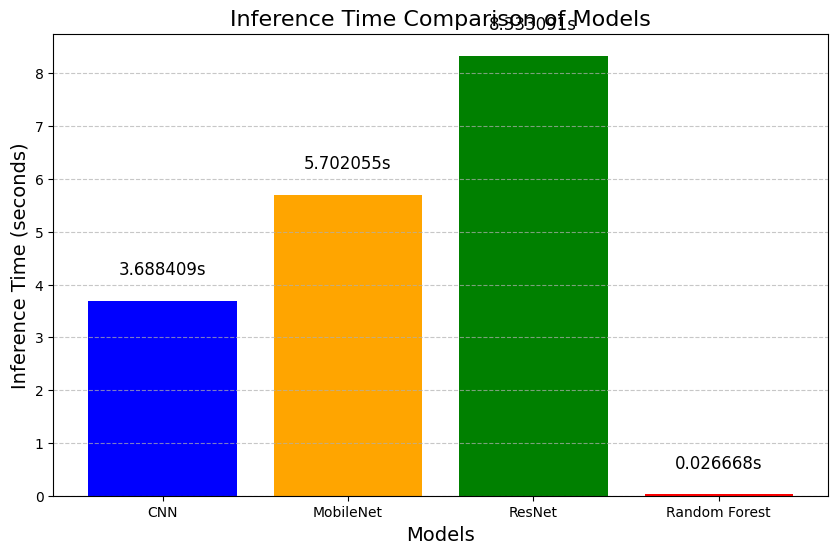

In [ ]:
import matplotlib.pyplot as plt

# Inference times provided (in seconds)
models = ['CNN', 'MobileNet', 'ResNet', 'Random Forest']
inference_times = [3.688409,  5.702055, 8.333091,0.026668]

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, inference_times, color=['blue', 'orange', 'green', 'red'])

# Add titles and labels
plt.title('Inference Time Comparison of Models', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('Inference Time (seconds)', fontsize=14)

# Annotate the bars with inference times
for i, v in enumerate(inference_times):
    plt.text(i, v + 0.5, f"{v:.6f}s", ha='center', fontsize=12, color='black')

# Show the grid and graph
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


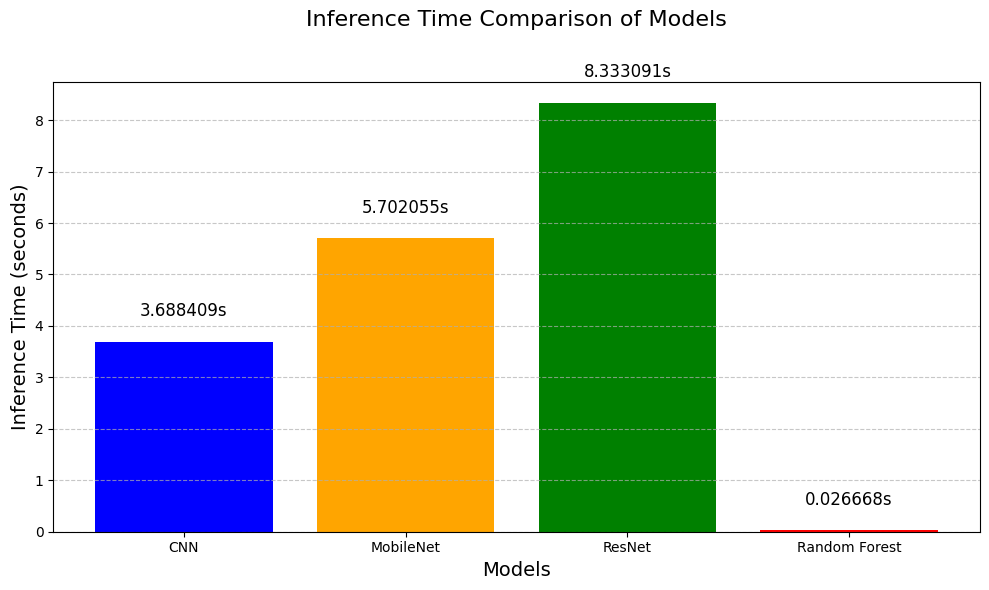

In [ ]:
import matplotlib.pyplot as plt

# Inference times provided (in seconds)
models = ['CNN', 'MobileNet', 'ResNet', 'Random Forest']
inference_times = [3.688409,5.702055, 8.333091, 0.026668]

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, inference_times, color=['blue', 'orange', 'green', 'red'])

# Add titles and labels with extra padding for the title
plt.title('Inference Time Comparison of Models', fontsize=16, pad=40)  # Increased pad value
plt.xlabel('Models', fontsize=14)
plt.ylabel('Inference Time (seconds)', fontsize=14)

# Annotate the bars with inference times
for i, v in enumerate(inference_times):
    plt.text(i, v + 0.5, f"{v:.6f}s", ha='center', fontsize=12, color='black')

# Ensure proper spacing and prevent overlapping
plt.tight_layout()

# Show the grid and graph
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
